### high_value_orders_classification  and "Target Variable Investigation"

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [6]:
original_df = pd.read_csv("../dataset/original_dataset/ecommerce_orders_dataset.csv")

In [7]:
original_df[["Order_Amount", "High_Value_Order"]].head()

,Order_Amount,High_Value_Order
0,68.20,No
1,38.73,No
2,153.66,No
3,298.37,No
4,105.75,No


In [8]:
original_df.groupby("High_Value_Order")["Order_Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
High_Value_Order,,,,,,,,
No,22499.0,144.255416,94.195631,6.67,67.40,120.19,205.365,388.17
Yes,7501.0,1083.114437,826.429620,388.19,521.36,778.83,1353.810,10314.27


In [9]:
df = original_df.copy()

In [10]:
print(df.shape)

(30000, 41)


In [11]:
df.head(10)

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No
5,613497,CUST000940,2023-01-01,2023,1,1,Sunday,1,32,Female,...,5,Processing,No,4.1,5844.78,30.29,125.38,Winter,No,Yes
6,600746,CUST004139,2023-01-01,2023,1,1,Sunday,1,25,Female,...,6,Delivered,No,5.0,1178.52,27.91,32.45,Winter,No,No
7,604774,CUST000543,2023-01-01,2023,1,1,Sunday,1,38,Female,...,6,Delivered,No,4.1,2535.68,10.14,11.85,Winter,No,No
8,600323,CUST003309,2023-01-01,2023,1,1,Sunday,1,48,Female,...,5,Delivered,No,3.4,598.88,17.93,19.06,Winter,No,No
9,608449,CUST006419,2023-01-01,2023,1,1,Sunday,1,31,Other,...,6,Shipped,No,4.5,1050.17,31.95,59.20,Winter,No,No


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 30000 non-null  int64  
 1   Customer_ID              30000 non-null  str    
 2   Order_Date               30000 non-null  str    
 3   Year                     30000 non-null  int64  
 4   Month                    30000 non-null  int64  
 5   Day                      30000 non-null  int64  
 6   Day_Of_Week              30000 non-null  str    
 7   Quarter                  30000 non-null  int64  
 8   Customer_Age             30000 non-null  int64  
 9   Customer_Gender          30000 non-null  str    
 10  Country                  30000 non-null  str    
 11  City                     30000 non-null  str    
 12  Customer_Segment         30000 non-null  str    
 13  Product_ID               30000 non-null  str    
 14  Product_Category         30000 no

In [13]:
print(df["High_Value_Order"].value_counts())

High_Value_Order
No     22499
Yes     7501
Name: count, dtype: int64


In [14]:
print(df["High_Value_Order"].value_counts(normalize=True)*100)

High_Value_Order
No     74.996667
Yes    25.003333
Name: proportion, dtype: float64


In [15]:
df.isnull().sum()

Order_ID                   0
Customer_ID                0
Order_Date                 0
Year                       0
Month                      0
Day                        0
Day_Of_Week                0
Quarter                    0
Customer_Age               0
Customer_Gender            0
Country                    0
City                       0
Customer_Segment           0
Product_ID                 0
Product_Category           0
Product_Subcategory        0
Brand                      0
Unit_Price                 0
Quantity                   0
Discount_Percent           0
Discount_Amount            0
Coupon_Used                0
Shipping_Cost              0
Tax_Amount                 0
Order_Amount               0
Payment_Method             0
Device_Type                0
Traffic_Source             0
Membership_Status          0
Shipping_Method            0
Warehouse_Region           0
Delivery_Days              0
Order_Status               0
Returned                   0
Review_Rating 

In [16]:
df.drop(
    columns=[
        "Order_ID",
        "Customer_ID",
        "Product_ID",
        "Order_Amount",
        "Profit_Amount",
        "Profit_Margin_Percent"
    ],
    inplace=True
)

In [17]:
X = df.drop("High_Value_Order", axis=1)
y =df["High_Value_Order"]

In [18]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns", len(numerical_cols))

Categorical Columns: 20
Numerical Columns 14


C:\Users\srava\AppData\Local\Temp\ipykernel_9056\142581708.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,          # use encoded labels
    test_size=0.20,
    stratify=y_encoded, # use encoded labels
    random_state=42
)

In [23]:
print(y_train.dtype)
print(np.unique(y_train))

int64
[0 1]


In [24]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [25]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['Order_Date','Year','Month',...,'Customer_Lifetime_Value','Season', 'Holiday_Season']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [26]:
y_pred = rf_model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9700


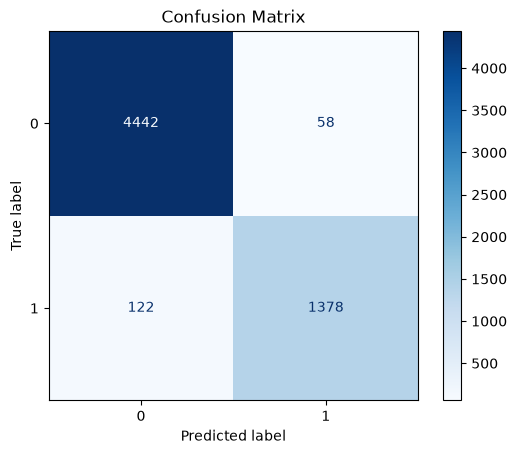

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4500
           1       0.96      0.92      0.94      1500

    accuracy                           0.97      6000
   macro avg       0.97      0.95      0.96      6000
weighted avg       0.97      0.97      0.97      6000



#### Importance



In [30]:
rf = rf_model.named_steps["classifier"]

In [31]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

In [32]:
importance = rf.feature_importances_

In [33]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [34]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
1598,remainder__Tax_Amount,0.163214
1601,remainder__Customer_Lifetime_Value,0.149251
1593,remainder__Unit_Price,0.138295
1497,cat__Product_Category_Electronics,0.089295
1596,remainder__Discount_Amount,0.065747
1594,remainder__Quantity,0.026883
1503,cat__Product_Subcategory_Accessories,0.019573
1526,cat__Product_Subcategory_Mobile,0.019550
1523,cat__Product_Subcategory_Laptop,0.017598
1522,cat__Product_Subcategory_Headphones,0.017102


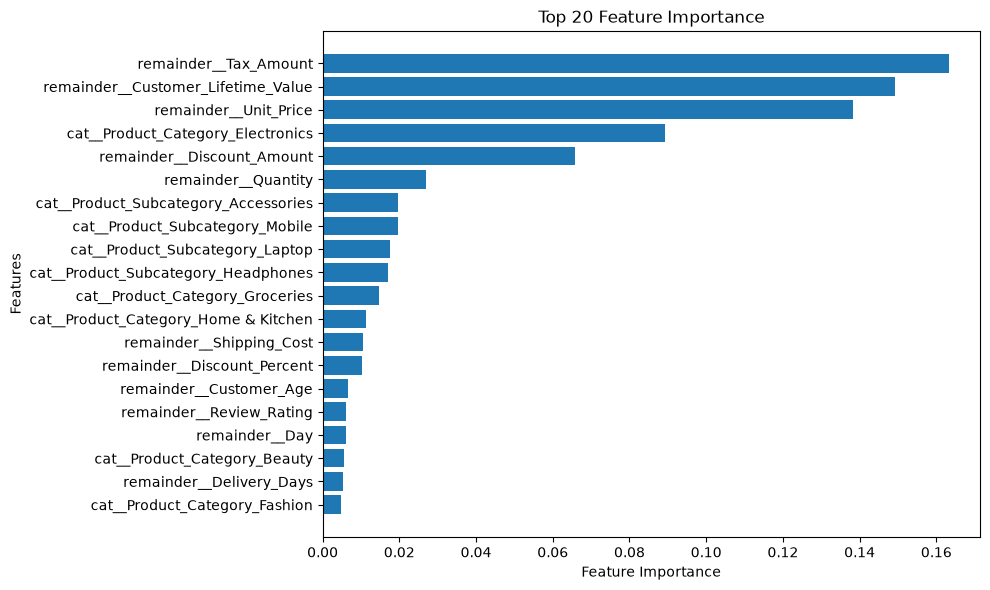

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(20),
    importance_df["Importance"].head(20)
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importance")

plt.tight_layout()

# Optional: Save the graph
plt.savefig("feature_importance_exp2.png", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
original_df.groupby("High_Value_Order")["Order_Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
High_Value_Order,,,,,,,,
No,22499.0,144.255416,94.195631,6.67,67.40,120.19,205.365,388.17
Yes,7501.0,1083.114437,826.429620,388.19,521.36,778.83,1353.810,10314.27


#### dython

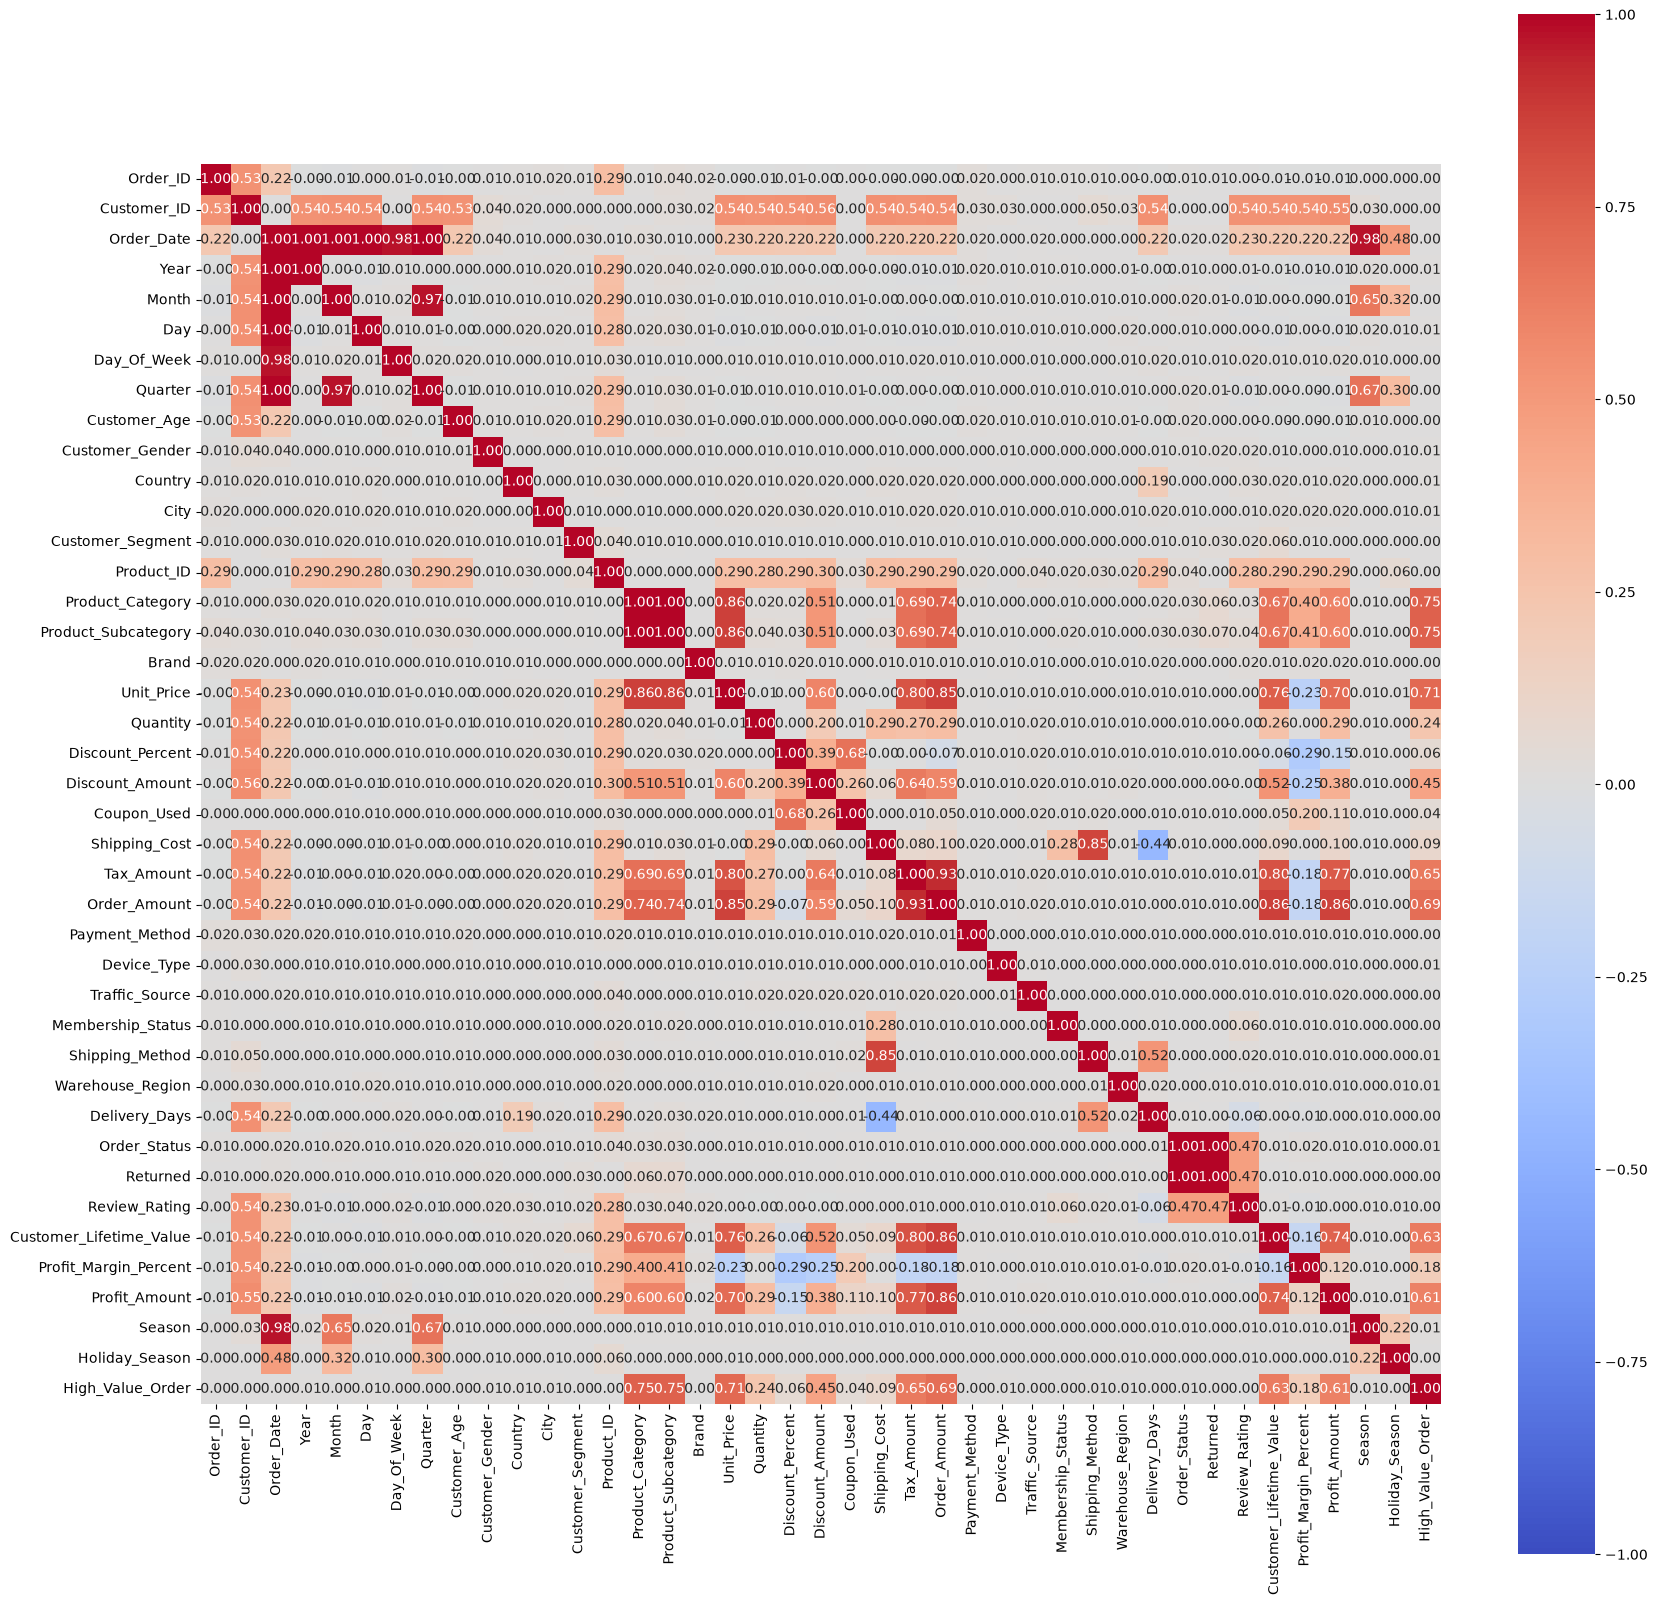

{'corr':                          Order_ID  Customer_ID  Order_Date      Year  \
 Order_ID                 1.000000     0.534290    0.224498 -0.003973   
 Customer_ID              0.534290     1.000000    0.000000  0.537928   
 Order_Date               0.224498     0.000000    1.000000  1.000000   
 Year                    -0.003973     0.537928    1.000000  1.000000   
 Month                   -0.008787     0.539673    1.000000  0.002944   
 Day                      0.002341     0.540463    1.000000 -0.010696   
 Day_Of_Week              0.010976     0.000000    0.975460  0.012240   
 Quarter                 -0.009870     0.539133    1.000000  0.003798   
 Customer_Age            -0.003918     0.534422    0.222876  0.002207   
 Customer_Gender          0.005985     0.041805    0.037254  0.003235   
 Country                  0.010533     0.017833    0.014103  0.012437   
 City                     0.021315     0.000000    0.000000  0.017500   
 Customer_Segment         0.011673     0.00

In [37]:
from dython.nominal import associations

associations(
    original_df,
    figsize=(20, 20),
    cmap="coolwarm",
    annot=True
)

In [38]:
print(rf_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Order_Date', 'Day_Of_Week',
                                                   'Customer_Gender', 'Country',
                                                   'City', 'Customer_Segment',
                                                   'Product_Category',
                                                   'Product_Subcategory',
                                                   'Brand', 'Coupon_Used',
                                                   'Payment_Method',
                                                   'Device_Type',
                                                   'Traffic_Source',
                                                   'Membership_Status',
                        

In [39]:
rf_model.named_steps["classifier"].feature_importances_

array([5.75523603e-06, 7.42747121e-05, 1.50028941e-05, ...,
       5.39560668e-03, 6.05400868e-03, 1.49251067e-01], shape=(1602,))

In [40]:
print(rf_model.named_steps)

{'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Order_Date', 'Day_Of_Week',
                                  'Customer_Gender', 'Country', 'City',
                                  'Customer_Segment', 'Product_Category',
                                  'Product_Subcategory', 'Brand', 'Coupon_Used',
                                  'Payment_Method', 'Device_Type',
                                  'Traffic_Source', 'Membership_Status',
                                  'Shipping_Method', 'Warehouse_Region',
                                  'Order_Status', 'Returned', 'Season',
                                  'Holiday_Season'])]), 'classifier': RandomForestClassifier(n_estimators=200, random_state=42)}


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = rf_model.named_steps["classifier"].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
1598,remainder__Tax_Amount,0.163214
1601,remainder__Customer_Lifetime_Value,0.149251
1593,remainder__Unit_Price,0.138295
1497,cat__Product_Category_Electronics,0.089295
1596,remainder__Discount_Amount,0.065747
1594,remainder__Quantity,0.026883
1503,cat__Product_Subcategory_Accessories,0.019573
1526,cat__Product_Subcategory_Mobile,0.019550
1523,cat__Product_Subcategory_Laptop,0.017598
1522,cat__Product_Subcategory_Headphones,0.017102


#### Top 20 encoded features.

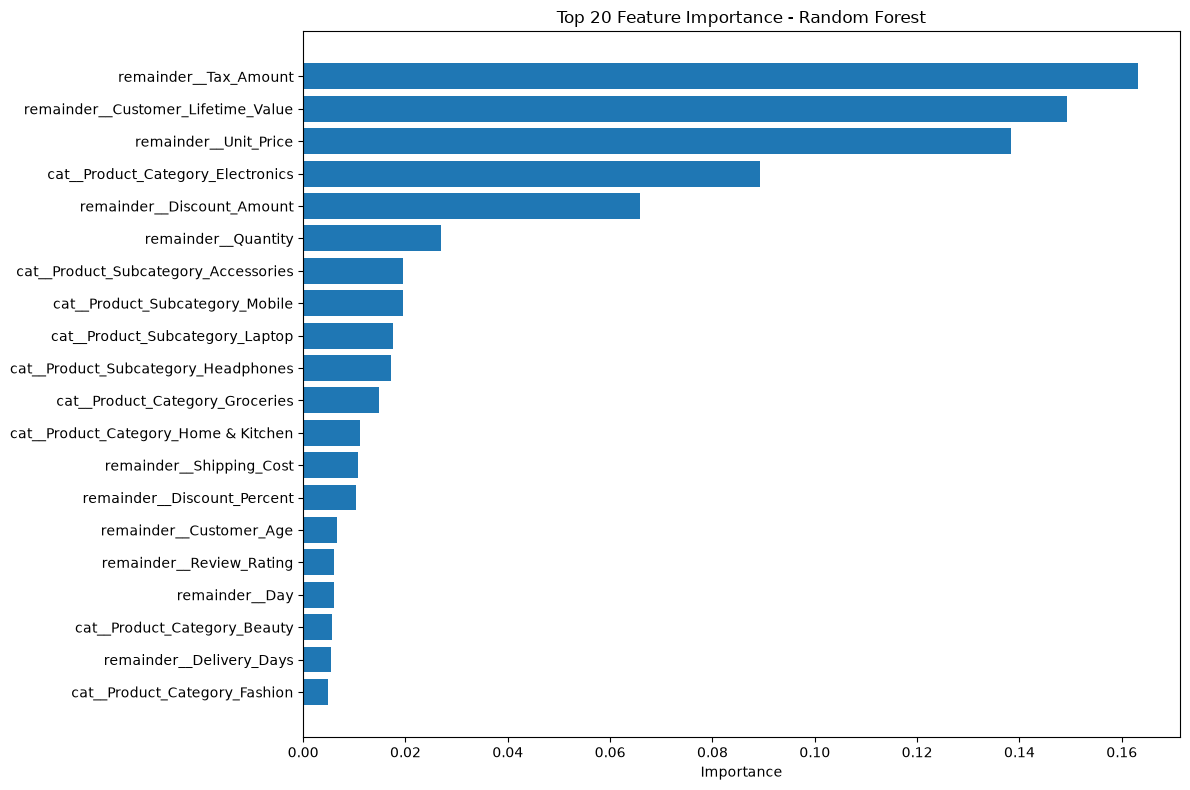

In [42]:
top20 = feature_importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

#### Aggregated feature importance (correctly aggregated).

,Original_Feature,Importance
17,Product,0.246044
25,Tax_Amount,0.163214
6,Customer_Lifetime_Value,0.149251
27,Unit_Price,0.138295
10,Discount_Amount,0.065747
15,Order,0.052827
18,Quantity,0.026883
7,Day,0.014083
24,Shipping_Cost,0.010629
2,Country,0.010613


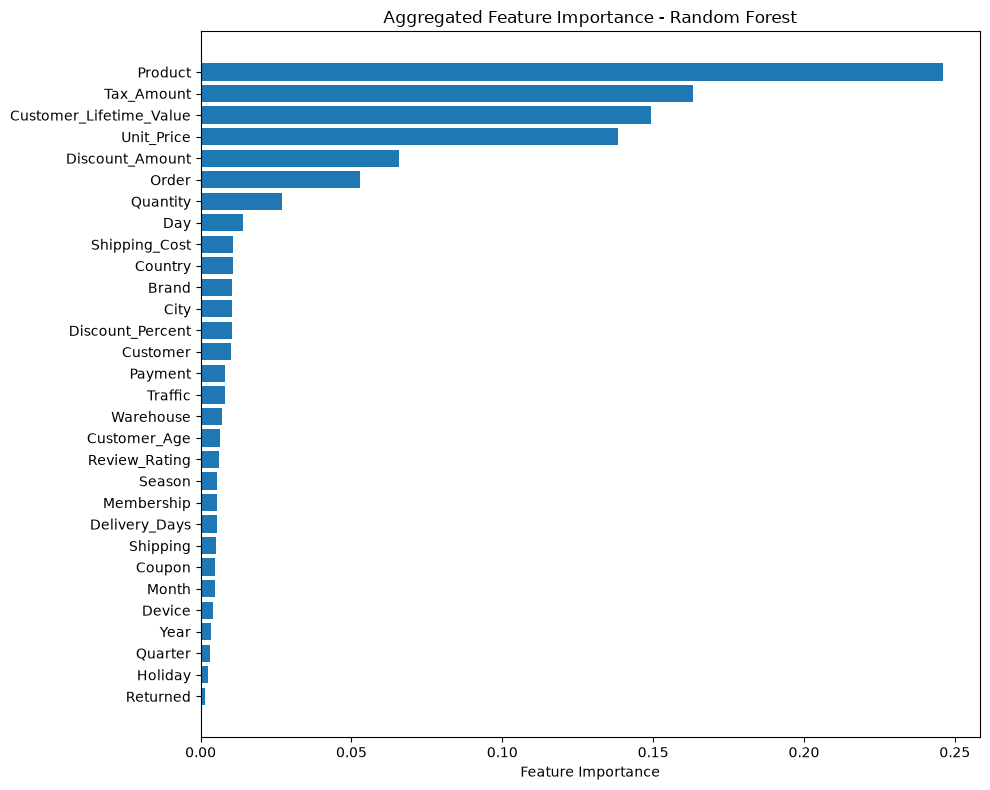

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importances = rf_model.named_steps["classifier"].feature_importances_

# Create DataFrame
fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Function to recover original feature name
def get_original_feature(feature):
    # OneHotEncoded categorical features
    if feature.startswith("cat__"):
        return feature.replace("cat__", "").split("_")[0]

    # Numerical features (passed through)
    elif feature.startswith("remainder__"):
        return feature.replace("remainder__", "")

    return feature

# Aggregate importances
fi["Original_Feature"] = fi["Feature"].apply(get_original_feature)

feature_importance = (
    fi.groupby("Original_Feature", as_index=False)["Importance"]
      .sum()
      .sort_values(by="Importance", ascending=False)
)

# Display
display(feature_importance)

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Original_Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Aggregated Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

### XGBoost

In [44]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [45]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

[0 1]


In [46]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [47]:
xgb_model.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['Order_Date','Year','Month',...,'Customer_Lifetime_Value','Season', 'Holiday_Season']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [48]:
y_pred_xgb = xgb_model.predict(X_test)

In [49]:
y_pred_labels = label_encoder.inverse_transform(y_pred_xgb)

In [50]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))

Accuracy: 0.9973

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4500
           1       0.99      0.99      0.99      1500

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



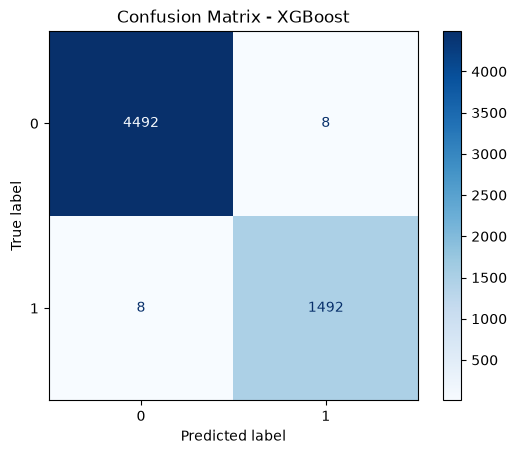

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [52]:
import pandas as pd

feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

importances = xgb_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
1598,remainder__Tax_Amount,0.425905
1601,remainder__Customer_Lifetime_Value,0.070824
1593,remainder__Unit_Price,0.062751
1497,cat__Product_Category_Electronics,0.055128
1594,remainder__Quantity,0.035932
1595,remainder__Discount_Percent,0.016396
1596,remainder__Discount_Amount,0.015296
1546,cat__Coupon_Used_Yes,0.011988
1545,cat__Coupon_Used_No,0.010074
1555,cat__Device_Type_Tablet,0.007196


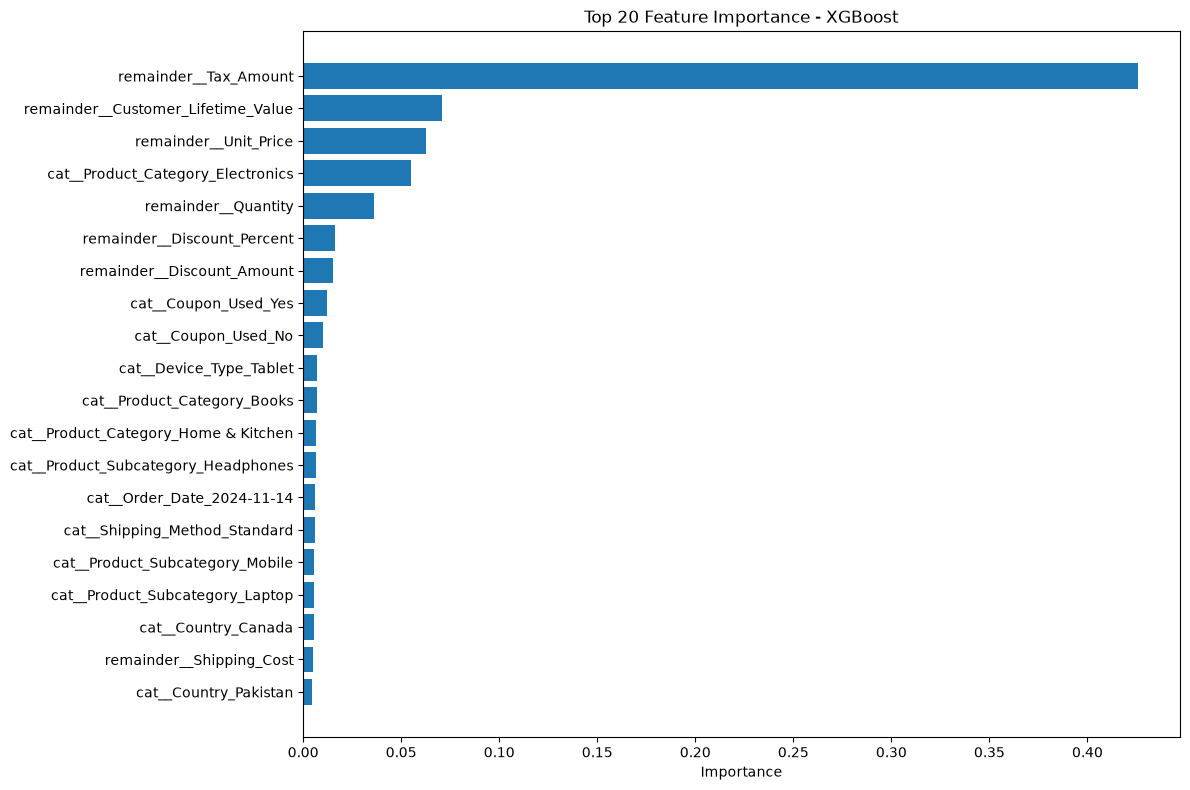

In [53]:
top20 = feature_importance.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top20["Feature"][::-1], top20["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

In [54]:
X_train.columns

Index(['Order_Date', 'Year', 'Month', 'Day', 'Day_Of_Week', 'Quarter',
       'Customer_Age', 'Customer_Gender', 'Country', 'City',
       'Customer_Segment', 'Product_Category', 'Product_Subcategory', 'Brand',
       'Unit_Price', 'Quantity', 'Discount_Percent', 'Discount_Amount',
       'Coupon_Used', 'Shipping_Cost', 'Tax_Amount', 'Payment_Method',
       'Device_Type', 'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Season', 'Holiday_Season'],
      dtype='str')

In [55]:
print(X_train.columns.tolist())

['Order_Date', 'Year', 'Month', 'Day', 'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country', 'City', 'Customer_Segment', 'Product_Category', 'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity', 'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost', 'Tax_Amount', 'Payment_Method', 'Device_Type', 'Traffic_Source', 'Membership_Status', 'Shipping_Method', 'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned', 'Review_Rating', 'Customer_Lifetime_Value', 'Season', 'Holiday_Season']


In [56]:
temp = df.copy()

temp["High_Value_Order"] = temp["High_Value_Order"].map({
    "No": 0,
    "Yes": 1
})

corr_features = [
    "Tax_Amount",
    "Customer_Lifetime_Value",
    "Unit_Price",
    "Quantity",
    "Discount_Amount",
    "High_Value_Order"
]

temp[corr_features].corr()

,Tax_Amount,Customer_Lifetime_Value,Unit_Price,Quantity,Discount_Amount,High_Value_Order
Tax_Amount,1.000000,0.799547,0.795631,0.271875,0.641471,0.646871
Customer_Lifetime_Value,0.799547,1.000000,0.756279,0.257869,0.524185,0.633292
Unit_Price,0.795631,0.756279,1.000000,-0.006856,0.601403,0.711186
Quantity,0.271875,0.257869,-0.006856,1.000000,0.200512,0.240948
Discount_Amount,0.641471,0.524185,0.601403,0.200512,1.000000,0.450617
High_Value_Order,0.646871,0.633292,0.711186,0.240948,0.450617,1.000000


In [57]:
df.groupby("High_Value_Order")["Tax_Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
High_Value_Order,,,,,,,,
No,22499.0,10.632398,8.609686,0.26,4.10,8.08,14.71,59.39
Yes,7501.0,84.668208,74.105585,10.98,38.52,60.01,104.06,1043.16


In [58]:
original_df[
    (original_df["Order_Amount"] >= 387) &
    (original_df["Order_Amount"] <= 390)
][["Order_Amount", "High_Value_Order"]].sort_values("Order_Amount")

,Order_Amount,High_Value_Order
4708,387.01,No
3718,387.06,No
12479,387.06,No
22997,387.06,No
6485,387.14,No
5859,387.19,No
22461,387.21,No
20125,387.25,No
7463,387.26,No
15963,387.27,No


In [59]:
quartiles = original_df["Order_Amount"].quantile([0.25, 0.50, 0.75])

print(quartiles)

0.25     82.9475
0.50    171.0300
0.75    388.1900
Name: Order_Amount, dtype: float64


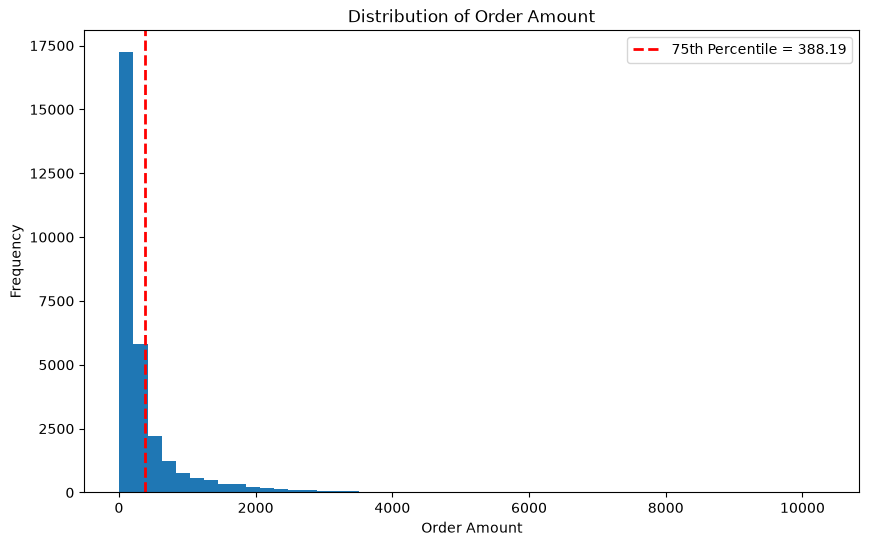

In [60]:
import matplotlib.pyplot as plt

threshold = original_df["Order_Amount"].quantile(0.75)

plt.figure(figsize=(10,6))

plt.hist(original_df["Order_Amount"], bins=50)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"75th Percentile = {threshold:.2f}"
)

plt.xlabel("Order Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Order Amount")
plt.legend()

plt.show()

C:\Users\srava\AppData\Local\Temp\ipykernel_9056\2975580715.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(original_df["Order_Amount"], vert=False)


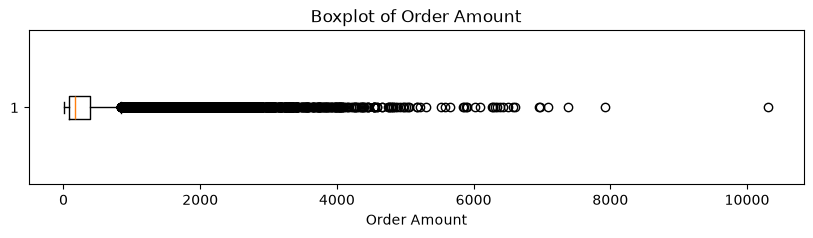

In [61]:
plt.figure(figsize=(10,2))

plt.boxplot(original_df["Order_Amount"], vert=False)

plt.title("Boxplot of Order Amount")
plt.xlabel("Order Amount")

plt.show()

In [62]:
threshold = original_df["Order_Amount"].quantile(0.75)

check = (
    (original_df["Order_Amount"] >= threshold)
    == (original_df["High_Value_Order"] == "Yes")
)

print("Rows matching threshold rule:", check.sum())
print("Total rows:", len(check))
print("Match Percentage:", check.mean() * 100)

Rows matching threshold rule: 30000
Total rows: 30000
Match Percentage: 100.0


In [63]:
%who

ColumnTransformer	 ConfusionMatrixDisplay	 LabelEncoder	 OneHotEncoder	 Pipeline	 RandomForestClassifier	 X	 XGBClassifier	 X_test	 
X_train	 accuracy	 accuracy_score	 associations	 categorical_cols	 check	 classification_report	 cm	 confusion_matrix	 
corr_features	 df	 disp	 f1_score	 feature_importance	 feature_names	 fi	 get_original_feature	 importance	 
importance_df	 importances	 label_encoder	 np	 numerical_cols	 original_df	 pd	 plt	 preprocessor	 
quartiles	 rf	 rf_model	 sns	 temp	 threshold	 top20	 train_test_split	 xgb_model	 
y	 y_encoded	 y_pred	 y_pred_labels	 y_pred_xgb	 y_test	 y_test_encoded	 y_train	 y_train_encoded	 



In [64]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ColumnTransformer        ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                        DataFrame                 Shape: (30000, 34)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (6000, 34)
X_train                  D

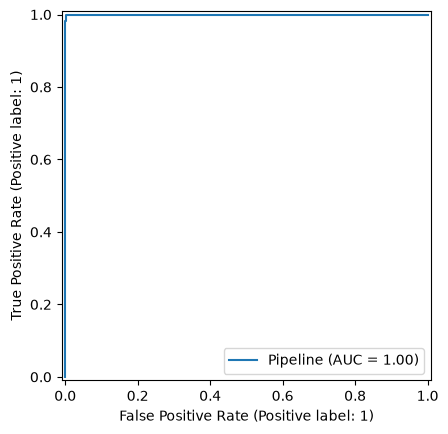

In [65]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test_encoded
)

In [66]:
import os
print(os.getcwd())

d:\CDAC PGCP BDA Projects\shopstream\notebooks


In [67]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [68]:
from sklearn.model_selection import cross_val_score

In [69]:
scores = cross_val_score(
    xgb_model,
    X,
    y_encoded,
    cv=5,
    scoring="f1"
)

print(scores)
print("Mean F1:", scores.mean())

[0.98933333 0.98997996 0.99100899 0.992      0.99067288]
Mean F1: 0.9905990338011337


In [70]:
param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7, 9],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5]
}

In [71]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=2,
    cv=2,
    scoring="f1",
    random_state=42,
    n_jobs=1,
    error_score="raise",
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=100, classifier__subsample=0.9; total time=   0.2s
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=100, classifier__subsample=0.9; total time=   0.2s
[CV] END classifier__colsample_bytree=0.9, classifier__learning_rate=0.2, classifier__max_depth=9, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__subsample=1.0; total time=   0.3s
[CV] END classifier__colsample_bytree=0.9, classifier__learning_rate=0.2, classifier__max_depth=9, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__subsample=1.0; total time=   0.3s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 0.9, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default

In [72]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 5, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.9}

Best CV F1 Score:
0.985541284456952


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9973333333333333
Precision: 0.9946666666666667
Recall   : 0.9946666666666667
F1 Score : 0.9946666666666667


In [74]:
import joblib

In [75]:
# joblib.dump(random_search.best_estimator_, "../ml/models/high_value_order_xgb_pipeline.pkl")

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

In [77]:
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)
xgb_precision = precision_score(y_test_encoded, y_pred_xgb)
xgb_recall = recall_score(y_test_encoded, y_pred_xgb)
xgb_f1 = f1_score(y_test_encoded, y_pred_xgb)

In [78]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})

comparison = comparison.sort_values(by="F1 Score", ascending=False)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
1,XGBoost,0.997333,0.994667,0.994667,0.994667
0,Random Forest,0.970000,0.959610,0.918667,0.938692


In [79]:
from sklearn.metrics import accuracy_score, f1_score

# Training predictions
train_pred = best_model.predict(X_train)

# Test predictions
test_pred = best_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

print("Train F1:", f1_score(y_train, train_pred))
print("Test F1 :", f1_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy : 0.9973333333333333
Train F1: 1.0
Test F1 : 0.9946666666666667
